In [2]:
import os
import zipfile
import shutil
import random
import requests

from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [3]:
from pathlib import Path
import requests
import zipfile

DATA_DIR = Path("datasets")
DATA_DIR.mkdir(exist_ok=True)

zip_path = DATA_DIR / "pothole.zip"

url = "https://github.com/jaygala24/pothole-detection/releases/download/v1.0.0/Pothole.Dataset.IVCNZ.zip"

if not zip_path.exists():

    print("Downloading dataset...")

    response = requests.get(url, stream=True)

    total = int(response.headers.get("content-length", 0))

    downloaded = 0

    with open(zip_path, "wb") as f:

        for chunk in response.iter_content(chunk_size=8192):

            if chunk:

                f.write(chunk)

                downloaded += len(chunk)

                print(
                    f"\r{downloaded/1024/1024:.1f} MB",
                    end=""
                )

    print("\nDownload complete.")

else:

    print("Dataset already downloaded.")

Dataset already downloaded.


In [4]:
extract_dir = DATA_DIR / "raw"

if not extract_dir.exists():

    with zipfile.ZipFile(zip_path, "r") as z:

        z.extractall(extract_dir)

print("Dataset extracted.")

Dataset extracted.


In [5]:
# Find all images recursively

images = list(extract_dir.rglob("*.jpg")) + list(extract_dir.rglob("*.png"))

# Find all labels recursively

labels = list(extract_dir.rglob("*.txt"))

print("Images :", len(images))
print("Labels :", len(labels))


# Show some paths

print("\nExample image:")
print(images[0])

print("\nExample label:")
print(labels[0])

Images : 1243
Labels : 1243

Example image:
datasets\raw\Pothole Dataset\img-1.jpg

Example label:
datasets\raw\Pothole Dataset\img-1.txt


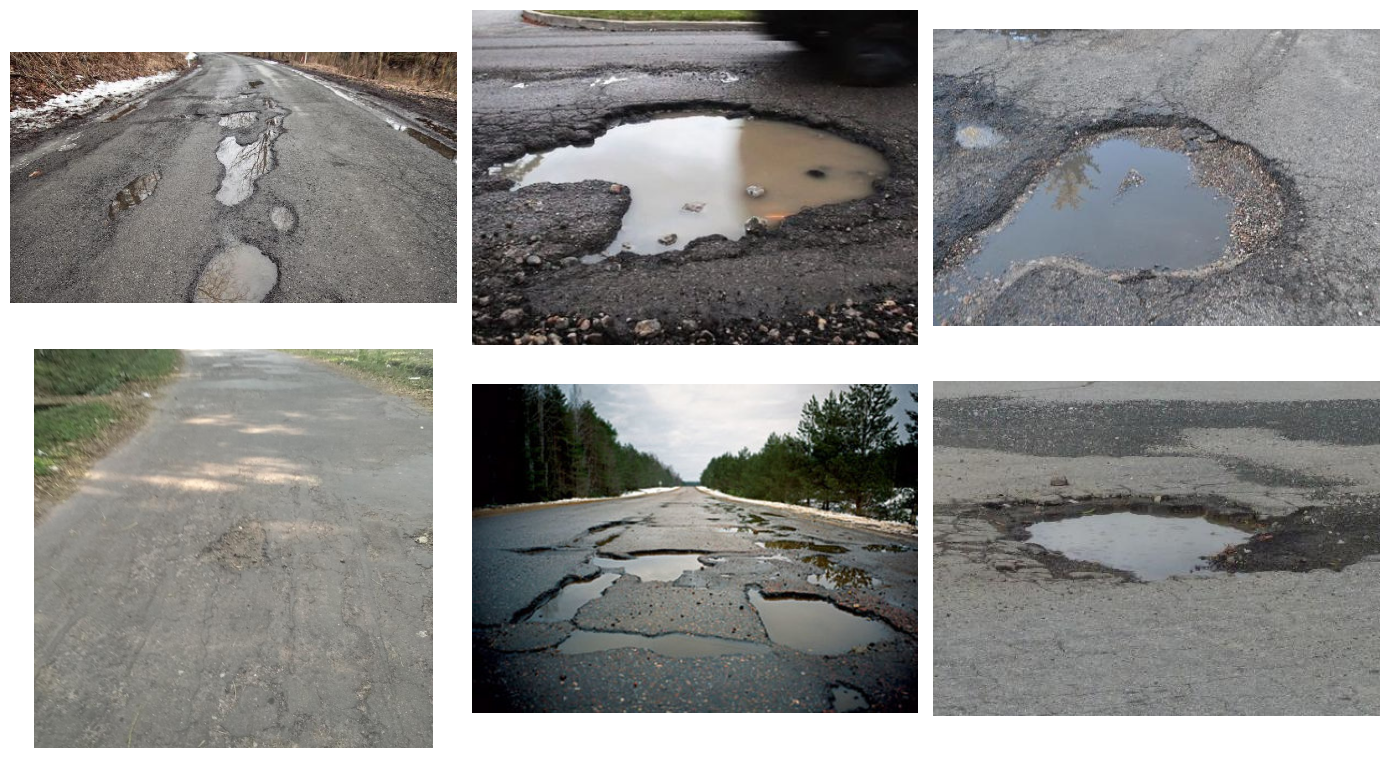

In [6]:
fig, axes = plt.subplots(2,3, figsize=(14,8))

for ax in axes.ravel():

    img_path = random.choice(images)

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path
import shutil
import random


SOURCE_DIR = extract_dir

YOLO_DIR = Path("datasets/pothole_yolo")

# Create folders

for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


print("YOLO structure created")

YOLO structure created


In [8]:
# Create image-label pairs

pairs = []

for img in images:

    label = img.with_suffix(".txt")

    if label.exists():
        pairs.append((img, label))


print("Total pairs:", len(pairs))

Total pairs: 1243


In [9]:
random.seed(42)

random.shuffle(pairs)


total = len(pairs)

train_size = int(total * 0.8)
val_size = int(total * 0.1)


train_pairs = pairs[:train_size]

val_pairs = pairs[train_size:train_size+val_size]

test_pairs = pairs[train_size+val_size:]


print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 994
Val: 124
Test: 125


In [10]:
def copy_pairs(pair_list, split):

    for img, label in pair_list:

        shutil.copy(
            img,
            YOLO_DIR / "images" / split / img.name
        )

        shutil.copy(
            label,
            YOLO_DIR / "labels" / split / label.name
        )


copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")
copy_pairs(test_pairs, "test")


print("Files copied successfully")

Files copied successfully


In [11]:
yaml_content = f"""
path: {YOLO_DIR.resolve()}

train: images/train
val: images/val
test: images/test


names:
  0: pothole
"""


yaml_path = YOLO_DIR / "data.yaml"


with open(yaml_path, "w") as f:
    f.write(yaml_content)


print(yaml_path)

datasets\pothole_yolo\data.yaml


In [12]:
for split in ["train","val","test"]:

    img_count = len(
        list((YOLO_DIR/"images"/split).glob("*"))
    )

    label_count = len(
        list((YOLO_DIR/"labels"/split).glob("*"))
    )

    print(
        split,
        "Images:",
        img_count,
        "Labels:",
        label_count
    )

train Images: 994 Labels: 994
val Images: 124 Labels: 124
test Images: 125 Labels: 125


In [13]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("Model loaded")

Model loaded


In [14]:
results = model.train(
    data=str(yaml_path),

    epochs=20,

    imgsz=640,

    batch=16,

    device=0,

    workers=4,

    optimizer="AdamW",

    lr0=0.001,

    patience=10,

    project="runs/pothole",

    name="yolo11n_pothole",

    save=True,

    plots=True
)

New https://pypi.org/project/ultralytics/8.4.131 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.129  Python-3.11.8 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\pothole_yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0

In [15]:
from pathlib import Path

# Search all best.pt files
weights = list(Path("runs").rglob("best.pt"))

print("Found models:")

for w in weights:
    print(w)

Found models:
runs\detect\runs\pothole\yolo11n_pothole\weights\best.pt
runs\detect\runs\pothole\yolo11n_pothole-4\weights\best.pt
runs\detect\runs\pothole\yolo11n_pothole-5\weights\best.pt


In [16]:
best_model = "runs\detect\runs\pothole\yolo11n_pothole-4\weights\best.pt"

In [17]:
from ultralytics import YOLO

best_model = "runs/detect/runs/pothole/yolo11n_pothole-4/weights/best.pt"

model = YOLO(best_model)

print("Model loaded successfully")

Model loaded successfully


In [18]:
metrics = model.val(
    data=str(yaml_path)
)

Ultralytics 8.4.129  Python-3.11.8 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 646.8395.2 MB/s, size: 59.5 KB)
val: Scanning D:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\datasets\pothole_yolo\labels\val.cache... 124 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 124/124  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4s/it 11.3s0.4s
                   all        124        499      0.645      0.611      0.645      0.324
Speed: 11.6ms preprocess, 11.8ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to D:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\runs\detect\val-2


In [19]:
print(f"mAP50: {metrics.box.map50:.4f}")

print(f"mAP50-95: {metrics.box.map:.4f}")

print(f"Precision: {metrics.box.mp:.4f}")

print(f"Recall: {metrics.box.mr:.4f}")

mAP50: 0.6451
mAP50-95: 0.3236
Precision: 0.6447
Recall: 0.6112



image 1/1 d:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\datasets\pothole_yolo\images\test\img-286.jpg: 480x640 2 potholes, 15.0ms
Speed: 4.8ms preprocess, 15.0ms inference, 10.2ms postprocess per image at shape (1, 3, 480, 640)


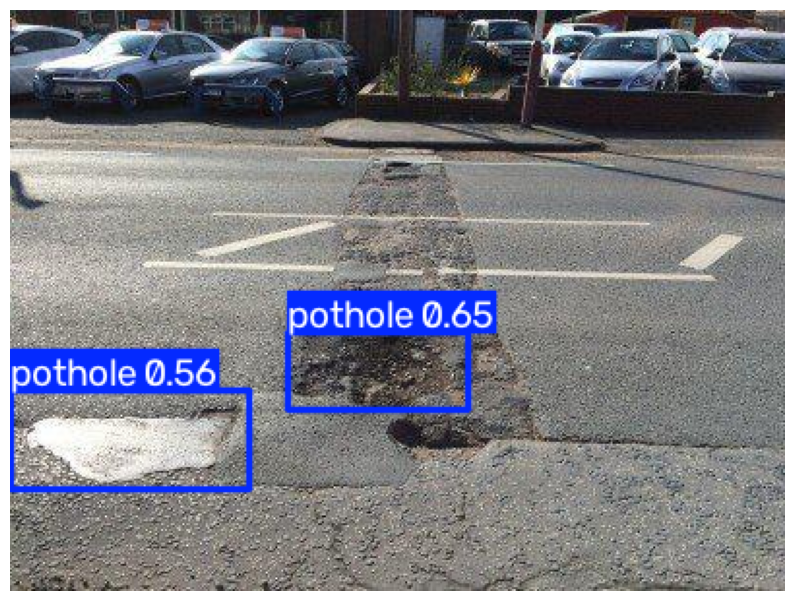

In [20]:
import random
import matplotlib.pyplot as plt
import cv2


test_images = list(
    (YOLO_DIR/"images"/"test").glob("*")
)


img_path = random.choice(test_images)


results = model.predict(
    source=str(img_path),
    conf=0.4
)


annotated = results[0].plot()


plt.figure(figsize=(10,8))

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.show()


image 1/1 d:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\test_images\road.jpg: 608x640 2 potholes, 49.3ms
Speed: 5.5ms preprocess, 49.3ms inference, 1.7ms postprocess per image at shape (1, 3, 608, 640)


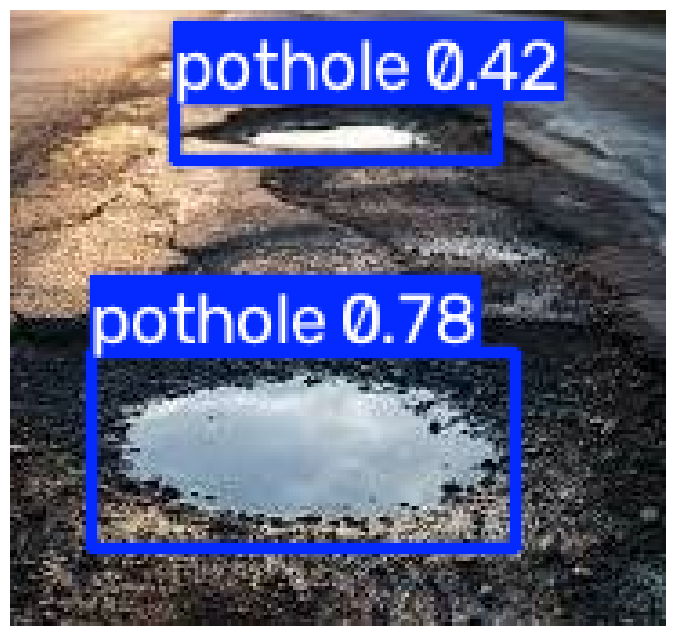

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2


IMAGE_PATH = "test_images/road.jpg"


results = model.predict(
    source=IMAGE_PATH,
    conf=0.4
)


output = results[0].plot()


plt.figure(figsize=(10,8))

plt.imshow(
    cv2.cvtColor(
        output,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

In [22]:
results = model.predict(
    source=IMAGE_PATH,
    conf=0.4,
    save=True
)

print("Prediction saved")


image 1/1 d:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\test_images\road.jpg: 608x640 2 potholes, 21.3ms
Speed: 4.0ms preprocess, 21.3ms inference, 2.0ms postprocess per image at shape (1, 3, 608, 640)
Results saved to D:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\runs\detect\predict-2
Prediction saved


In [23]:
result = results[0]


boxes = result.boxes


for box in boxes:

    cls = int(box.cls[0])

    conf = float(box.conf[0])

    print(
        "Class:",
        cls,
        "Confidence:",
        round(conf,3)
    )

Class: 0 Confidence: 0.781
Class: 0 Confidence: 0.424


In [24]:
VIDEO_PATH = "test_videos/road_video.mp4"


model.predict(
    source=VIDEO_PATH,
    conf=0.4,
    save=True
)


print("Video processed")


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/218) d:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\test_videos\road_video.mp4: 640x384 (no detections), 48.3ms
video 1/1 (frame 2/218) d:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\test_videos\road_video.mp4: 640x384 (no detections), 17.6ms
video 1/1 (frame 3/218) d:\Computer Vision Projects\6.Pothole Detection using YOLO11\notebooks\test_videos\road_video.mp4: 640x384 (no detections), 18.3

In [25]:
import cv2
from IPython.display import display, clear_output
from PIL import Image
import time


cap = cv2.VideoCapture(0)


while True:

    ret, frame = cap.read()

    if not ret:
        print("Camera not detected")
        break


    results = model.predict(
        frame,
        conf=0.4,
        verbose=False
    )


    annotated = results[0].plot()


    # Convert BGR -> RGB
    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )


    display(
        Image.fromarray(annotated)
    )


    clear_output(wait=True)


    time.sleep(0.05)


cap.release()

Camera not detected


In [26]:
from pathlib import Path
import shutil

Path("models").mkdir(exist_ok=True)

source = Path(
    "runs/detect/runs/pothole/yolo11n_pothole-4/weights/best.pt"
)

destination = Path(
    "models/best.pt"
)

shutil.copy(source, destination)

print("Model copied:", destination)

Model copied: models\best.pt
